In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.metrics import root_mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
np.random.seed(42)

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
data = pd.read_json('drive/MyDrive/hockey hackathon ml/hockey_data.json')
#data = pd.read_json("hockey_data.json")

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#### Datetime

In [6]:
data["date"] = pd.to_datetime(data["date"])
data["month"] = data["date"].dt.month
data["day_of_week"] = data["date"].dt.dayofweek
data["is_weekend"] = data["day_of_week"].apply(lambda x: 1 if x >= 5 else 0)

#### One-hot encoding

In [7]:
categorical_features = ["visit_team", "home_team", "game_type"]

#### Aggregate Historical Team Performance (Over their last 3 matches)

In [8]:
data["visit_team_avg_goals"] = data.groupby("visit_team")[
    "visit_score_total"
].transform(lambda x: x.shift().rolling(window=3, min_periods=1).mean())
data["home_team_avg_goals"] = data.groupby("home_team")["home_score_total"].transform(
    lambda x: x.shift().rolling(window=3, min_periods=1).mean()
)
data["visit_team_avg_shots"] = data.groupby("visit_team")[
    "visit_shots_total"
].transform(lambda x: x.shift().rolling(window=3, min_periods=1).mean())
data["home_team_avg_shots"] = data.groupby("home_team")["home_shots_total"].transform(
    lambda x: x.shift().rolling(window=3, min_periods=1).mean()
)
data["visit_team_avg_penalties"] = data.groupby("visit_team")[
    "visit_penalties"
].transform(lambda x: x.shift().rolling(window=3, min_periods=1).mean())
data["home_team_avg_penalties"] = data.groupby("home_team")["home_penalties"].transform(
    lambda x: x.shift().rolling(window=3, min_periods=1).mean()
)

#### Drop the first matches (since average stats is N/A)

In [9]:
data = data.dropna()

#### Splitting

In [10]:
numeric_features = [
    "month",
    "day_of_week",
    "is_weekend",
    "visit_team_avg_goals",
    "home_team_avg_goals",
    "visit_team_avg_shots",
    "home_team_avg_shots",
    "visit_team_avg_penalties",
    "home_team_avg_penalties",
]

features = numeric_features + categorical_features

targets = ["visit_score_total", "home_score_total"]

X = data[features]
y = data[targets]

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

#### Building Pipeline

In [12]:
numeric_transformer = StandardScaler()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ],
    remainder="drop",
)

In [13]:
from sklearn.ensemble import RandomForestRegressor

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", RandomForestRegressor(random_state=42)),
    ]
)

#### Train the model

In [14]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['month', 'day_of_week',
                                                   'is_weekend',
                                                   'visit_team_avg_goals',
                                                   'home_team_avg_goals',
                                                   'visit_team_avg_shots',
                                                   'home_team_avg_shots',
                                                   'visit_team_avg_penalties',
                                                   'home_team_avg_penalties']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['visit_team', 'home_team',
                                                   'game_type'])])),
                ('regressor', RandomForestRegressor(random_state=42))])

In [15]:
y_pred = model.predict(X_test)

In [16]:
rmse_visit = np.sqrt(root_mean_squared_error(y_test["visit_score_total"], y_pred[:, 0]))
rmse_home = np.sqrt(root_mean_squared_error(y_test["home_score_total"], y_pred[:, 1]))
print(f"RMSE for Visit Score: {rmse_visit}")
print(f"RMSE for Home Score: {rmse_home}")

RMSE for Visit Score: 1.2639547086366152
RMSE for Home Score: 1.339870516061839


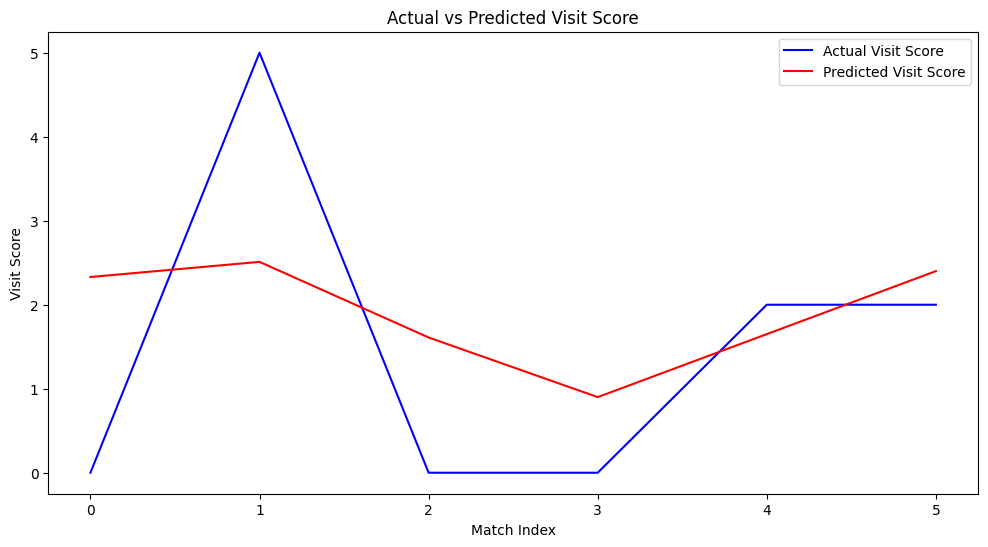

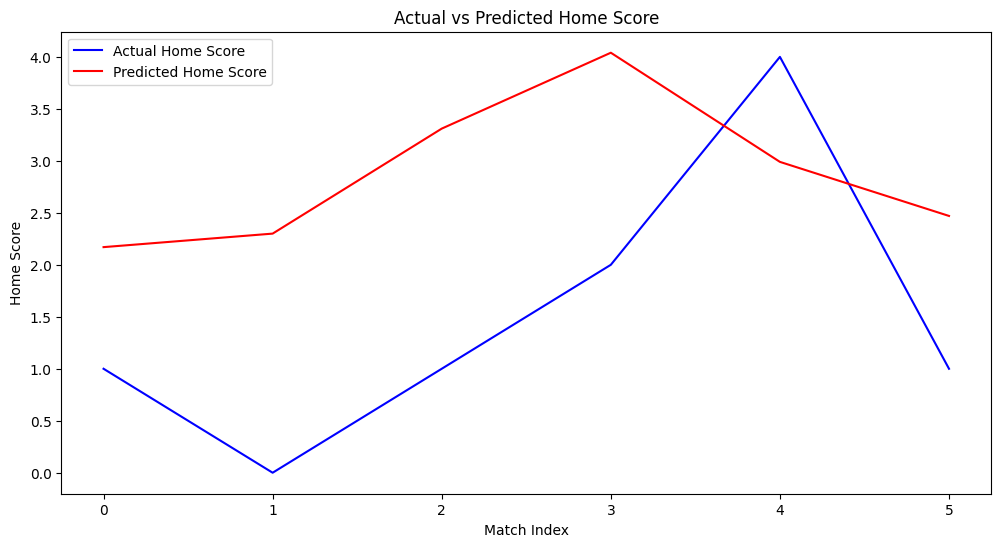

In [17]:
plt.figure(figsize=(12, 6))
plt.plot(y_test["visit_score_total"].values, label="Actual Visit Score", color="b")
plt.plot(y_pred[:, 0], label="Predicted Visit Score", color="r")
plt.xlabel("Match Index")
plt.ylabel("Visit Score")
plt.title("Actual vs Predicted Visit Score")
plt.legend()
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(y_test["home_score_total"].values, label="Actual Home Score", color="b")
plt.plot(y_pred[:, 1], label="Predicted Home Score", color="r")
plt.xlabel("Match Index")
plt.ylabel("Home Score")
plt.title("Actual vs Predicted Home Score")
plt.legend()
plt.show()

In [18]:
# Step 11: Predict Upcoming Matches
def predict_upcoming_match(datetime, home_team, visit_team):
    # Create a DataFrame for the upcoming match
    upcoming_match = pd.DataFrame(
        {
            "date": [datetime],
            "visit_team": [visit_team],
            "home_team": [home_team],
            "game_type": ["Non-Conference"],  # Example game type, adjust as needed
        }
    )

    # Extract date-related features
    upcoming_match["date"] = pd.to_datetime(upcoming_match["date"])
    upcoming_match["month"] = upcoming_match["date"].dt.month
    upcoming_match["day_of_week"] = upcoming_match["date"].dt.dayofweek
    upcoming_match["is_weekend"] = upcoming_match["day_of_week"].apply(
        lambda x: 1 if x >= 5 else 0
    )

    # Calculate historical statistics for the upcoming match
    historical_data = data.copy()
    historical_data["visit_score_total"] = pd.to_numeric(
        historical_data["visit_score_total"], errors="coerce"
    )
    historical_data["visit_shots_total"] = pd.to_numeric(
        historical_data["visit_shots_total"], errors="coerce"
    )
    historical_data["visit_penalties"] = pd.to_numeric(
        historical_data["visit_penalties"], errors="coerce"
    )
    historical_data["home_score_total"] = pd.to_numeric(
        historical_data["home_score_total"], errors="coerce"
    )
    historical_data["home_shots_total"] = pd.to_numeric(
        historical_data["home_shots_total"], errors="coerce"
    )
    historical_data["home_penalties"] = pd.to_numeric(
        historical_data["home_penalties"], errors="coerce"
    )

    upcoming_match = upcoming_match.merge(
        historical_data.groupby("visit_team")
        .agg(
            visit_team_avg_goals=(
                "visit_score_total",
                lambda x: pd.to_numeric(x, errors="coerce").tail(3).mean(),
            ),
            visit_team_avg_shots=(
                "visit_shots_total",
                lambda x: pd.to_numeric(x, errors="coerce").tail(3).mean(),
            ),
            visit_team_avg_penalties=(
                "visit_penalties",
                lambda x: pd.to_numeric(x, errors="coerce").tail(3).mean(),
            ),
        )
        .reset_index(),
        how="left",
        on="visit_team",
    )

    upcoming_match = upcoming_match.merge(
        historical_data.groupby("home_team")
        .agg(
            home_team_avg_goals=(
                "home_score_total",
                lambda x: pd.to_numeric(x, errors="coerce").tail(3).mean(),
            ),
            home_team_avg_shots=(
                "home_shots_total",
                lambda x: pd.to_numeric(x, errors="coerce").tail(3).mean(),
            ),
            home_team_avg_penalties=(
                "home_penalties",
                lambda x: pd.to_numeric(x, errors="coerce").tail(3).mean(),
            ),
        )
        .reset_index(),
        how="left",
        on="home_team",
    )

    # Fill NaNs with historical averages
    upcoming_match.fillna(historical_data.mean(numeric_only=True), inplace=True)

    # Select Features for Prediction
    features_upcoming = [
        "month",
        "day_of_week",
        "is_weekend",
        "visit_team_avg_goals",
        "home_team_avg_goals",
        "visit_team_avg_shots",
        "home_team_avg_shots",
        "visit_team_avg_penalties",
        "home_team_avg_penalties",
    ] + categorical_features

    X_upcoming = upcoming_match[features_upcoming]

    # Predict Scores for Upcoming Match
    y_upcoming_pred = model.predict(X_upcoming)

    print(f"Predicted Visit Score for Upcoming Match: {y_upcoming_pred[0][0]}")
    print(f"Predicted Home Score for Upcoming Match: {y_upcoming_pred[0][1]}")

In [19]:
predict_upcoming_match("2025-01-04", "Northeastern", "Yale")

Predicted Visit Score for Upcoming Match: 1.79
Predicted Home Score for Upcoming Match: 2.39


In [20]:
predict_upcoming_match("2025-1-18", "Providence", "Northeastern", )

Predicted Visit Score for Upcoming Match: 2.0
Predicted Home Score for Upcoming Match: 2.4
